Train shape: (521, 10)  y mean: 0.5335892514395394
Test  shape: (51, 10)  y mean: 0.7058823529411765
scale_pos_weight = 0.8741007194244604
Fold 1 AUC: 0.8869 (val size=86)
Fold 2 AUC: 0.9048 (val size=86)
Fold 3 AUC: 0.6882 (val size=86)
Fold 4 AUC: 0.9531 (val size=86)
Fold 5 AUC: 0.8627 (val size=86)

CV AUC mean: 0.8591626789604729 std: 0.09045507883640878

=== Test (2025) ===
ROC-AUC: 0.7370370370370369
              precision    recall  f1-score   support

           0      0.526     0.667     0.588        15
           1      0.844     0.750     0.794        36

    accuracy                          0.725        51
   macro avg      0.685     0.708     0.691        51
weighted avg      0.750     0.725     0.734        51

Confusion matrix:
 [[10  5]
 [ 9 27]]

=== Feature importance (XGBoost) ===
lag_1          0.232742
roll_mean_4    0.191142
roll_sum_4     0.146846
month          0.097971
weekofyear     0.089997
lag_2          0.058144
roll_sum_8     0.055151
roll_mean_8    0.0

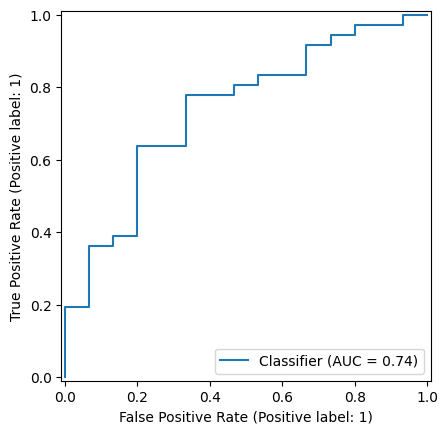

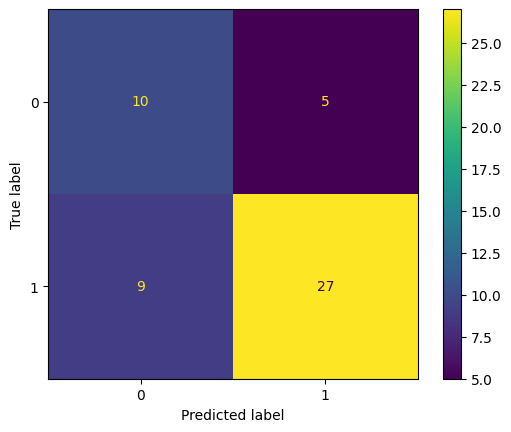

In [37]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

# =========================
# 1️⃣ Load data
# =========================
TRAIN_PATH = "../data/processed/train_table_train_2015_2024.parquet"
TEST_PATH  = "../data/processed/train_table_test_2025.parquet"

train = pd.read_parquet(TRAIN_PATH).sort_values("time_bin").reset_index(drop=True)
test  = pd.read_parquet(TEST_PATH).sort_values("time_bin").reset_index(drop=True)

# =========================
# 2️⃣ Features / labels
# =========================
FEATURES = [
    "lag_1","lag_2","lag_4",
    "roll_mean_4","roll_sum_4",
    "roll_mean_8","roll_sum_8","roll_std_8",
    "month","weekofyear"
]

FEATURES = [c for c in FEATURES if c in train.columns and c in test.columns]

X_train = train[FEATURES]
y_train = train["y"].astype(int)

X_test  = test[FEATURES]
y_test  = test["y"].astype(int)

print("Train shape:", X_train.shape, " y mean:", float(y_train.mean()))
print("Test  shape:", X_test.shape,  " y mean:", float(y_test.mean()))

# =========================
# 3️⃣ Handle imbalance
# =========================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", scale_pos_weight)

# =========================
# 4️⃣ Model
# =========================
model = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=2,
    reg_alpha=0.5,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

# =========================
# 5️⃣ Time-series CV
# =========================
tscv = TimeSeriesSplit(n_splits=5)
cv_aucs = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_va)[:, 1]

    auc = roc_auc_score(y_va, proba)
    cv_aucs.append(auc)
    print(f"Fold {fold} AUC: {auc:.4f} (val size={len(va_idx)})")

print("\nCV AUC mean:", np.mean(cv_aucs), "std:", np.std(cv_aucs))

# =========================
# 6️⃣ Final train → Test 2025
# =========================
model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = model.predict(X_test)

print("\n=== Test (2025) ===")
print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print(classification_report(y_test, test_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))

# =========================
# 7️⃣ Plots
# =========================
RocCurveDisplay.from_predictions(y_test, test_proba)
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)

# =========================
# 8️⃣ Feature importance
# =========================
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\n=== Feature importance (XGBoost) ===")
print(imp)
print("\nTop 5 features:")
print(imp.head(5))